<a href="https://colab.research.google.com/github/yashkapur0403/Yash_Kapur_ML_Lab_Work/blob/main/ANN_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [19]:
import tensorflow as tf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Conv1D, MaxPooling1D, Flatten
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix

import warnings
warnings.filterwarnings('ignore')

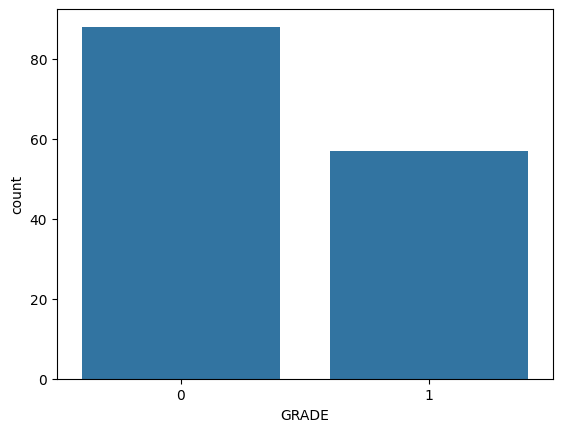

In [20]:
df = pd.read_csv('DATA (1).csv')
df = df.drop(columns=['STUDENT ID'])

df = df.apply(pd.to_numeric, errors='ignore')
df.fillna(df.median(numeric_only=True), inplace=True)

df['GRADE'] = df['GRADE'].apply(lambda x: 1 if x >= 4 else 0)

sns.countplot(x='GRADE', data=df)
plt.show()

X = df.drop('GRADE', axis=1).values
y = df['GRADE'].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

In [25]:
ann_model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    BatchNormalization(),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])

ann_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 249ms/step
0.5862069129943848
              precision    recall  f1-score   support

           0       0.59      0.94      0.73        17
           1       0.50      0.08      0.14        12

    accuracy                           0.59        29
   macro avg       0.55      0.51      0.44        29
weighted avg       0.55      0.59      0.49        29



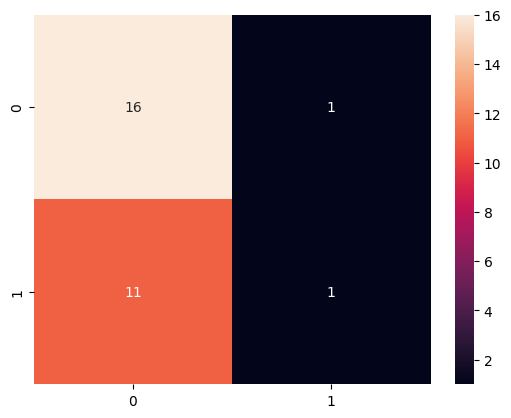

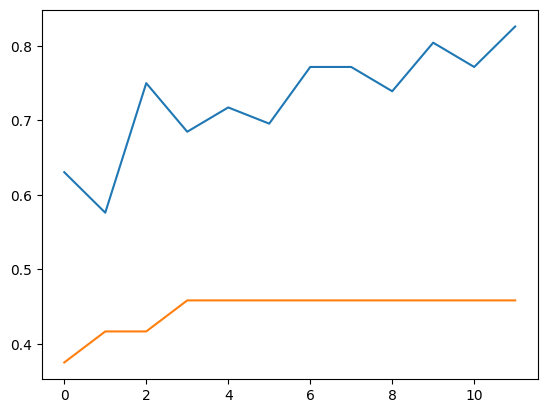

In [26]:
history_ann = ann_model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=16,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=0
)

ann_loss, ann_acc = ann_model.evaluate(X_test, y_test, verbose=0)

y_pred_ann = (ann_model.predict(X_test) > 0.5).astype(int).flatten()

print(ann_acc)
print(classification_report(y_test, y_pred_ann))

cm_ann = confusion_matrix(y_test, y_pred_ann)
sns.heatmap(cm_ann, annot=True, fmt='d')
plt.show()

plt.plot(history_ann.history['accuracy'])
plt.plot(history_ann.history['val_accuracy'])
plt.show()

In [27]:
X_train_cnn = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test_cnn = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

cnn_model = Sequential([
    Conv1D(32, 3, activation='relu', input_shape=(X_train.shape[1],1)),
    BatchNormalization(),
    MaxPooling1D(2),
    Flatten(),
    Dense(32, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

cnn_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 291ms/step
0.6896551847457886
              precision    recall  f1-score   support

           0       0.68      0.88      0.77        17
           1       0.71      0.42      0.53        12

    accuracy                           0.69        29
   macro avg       0.70      0.65      0.65        29
weighted avg       0.70      0.69      0.67        29



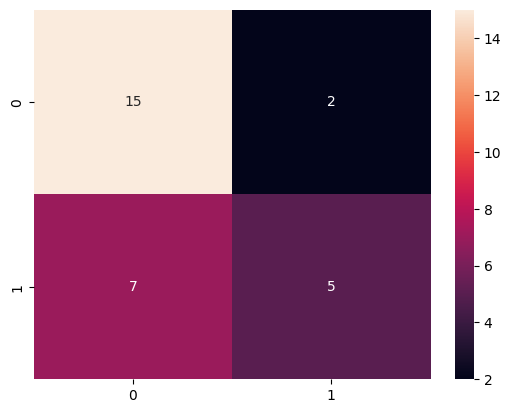

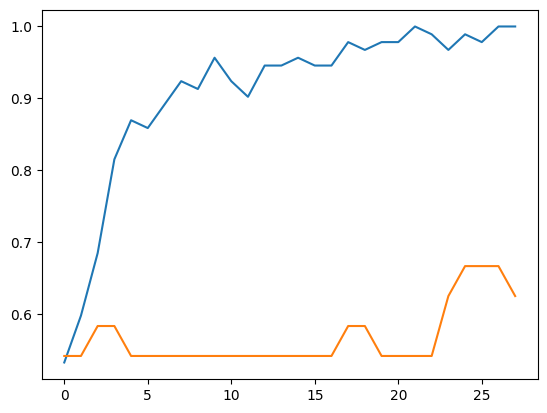

In [28]:
history_cnn = cnn_model.fit(
    X_train_cnn, y_train,
    epochs=100,
    batch_size=16,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=0
)

cnn_loss, cnn_acc = cnn_model.evaluate(X_test_cnn, y_test, verbose=0)

y_pred_cnn = (cnn_model.predict(X_test_cnn) > 0.5).astype(int).flatten()

print(cnn_acc)
print(classification_report(y_test, y_pred_cnn))

cm_cnn = confusion_matrix(y_test, y_pred_cnn)
sns.heatmap(cm_cnn, annot=True, fmt='d')
plt.show()

plt.plot(history_cnn.history['accuracy'])
plt.plot(history_cnn.history['val_accuracy'])
plt.show()